# 01 · A Self-Organising Map on a flat grid (PlaneSOM)

`PlaneSOM` puts its neurons on mtGeodesicDome's `Plane`: a hexagonal grid (6 neighbours per neuron) or a
rectilinear one (4), either with borders or wrapping around like a torus. Every neuron holds a weight vector with
one value per attribute of the data. This notebook loads data, trains a map, queries it and explores it in the
two linked viewers.

Script version: [`examples/01_plane_som.py`](../01_plane_som.py) · Needs: numpy, mtgeodesicdome, matplotlib, ipywidgets
(optional: `ipympl` for live figures)

<sub>SPDX-License-Identifier: AGPL-3.0-or-later · Copyright (C) 2022-2026 Masahiro Takatsuka. See the NOTICE file for attribution terms.</sub>

## Set-up

In [1]:
import nb_setup  # makes mt.geodesicsom importable from a checkout; helpers for the controls below

WIDGET = nb_setup.setup()  # live figures with ipympl, static images otherwise

figures: live (ipympl) -- drag the maps, click neurons, use the buttons on the figures


In [2]:
import ipywidgets as widgets
import numpy as np
from mt.geodesicdome.grid.plane import Lattice, Topology

from mt.geodesicsom import datasets
from mt.geodesicsom.gui import explore
from mt.geodesicsom.PlaneSOM import PlaneSOM
from mt.geodesicsom.som import InitializationType

## 1. Data

`datasets.load` takes the name of a sample shipped with the package or the path of a CSV file (a header row; the
numeric columns become attributes, empty cells are missing values; `label_column` names a column of class labels).

In [3]:
for name, description in datasets.samples().items():
    print(f'{name:9s} {description}')

animals   16 animals x 13 binary attributes, one label each (Ritter & Kohonen 1989)
clusters  560 samples x 12 attributes, 7 labelled Gaussian clusters (synthetic)
iris      150 flowers x 4 measurements, 3 species (Fisher 1936)
penguins  342 penguins x 4 measurements, 3 species (Palmer penguins, CC0)
wine      178 wines x 13 chemical measurements, 3 cultivars (UCI, CC BY 4.0)


In [4]:
DATA = 'clusters'                      # a sample name, 'colours', or a CSV path

x, labels, names = datasets.load(DATA)
if DATA != 'colours':
    x = datasets.standardise(x)        # so that no attribute dominates the Euclidean distance
print(f'{x.shape[0]} samples, {x.shape[1]} attributes:', ', '.join(names))

560 samples, 12 attributes: feature_1, feature_2, feature_3, feature_4, feature_5, feature_6, feature_7, feature_8, feature_9, feature_10, feature_11, feature_12


## 2. Train

A 20 × 30 hexagonal map with borders, initialised linearly (spread over the first two principal components),
then batch-trained. The **quantisation error** (QE) is the mean distance from a sample to its best matching
neuron; the **topographic error** (TE) is the share of samples whose two best neurons are not neighbours.

In [5]:
ROWS, COLS, EPOCHS = 20, 30, 30

som = PlaneSOM(ROWS, COLS, lattice=Lattice.Hexagonal, topology=Topology.Plane, seed=0)
som.initialise(InitializationType.Linear, x)
print(som)
print(f'  before training: quantisation error {som.quantisation_error(x):.3f}')
som.train(x, epochs=EPOCHS)                  # batch training; mode='online' also works
print(f'  after {EPOCHS} epochs: quantisation error {som.quantisation_error(x):.3f}, '
      f'topographic error {som.topographic_error(x):.3f}')

PlaneSOM(row=20, col=30, lattice=Hexagonal, topology=Plane, dim=12)
  before training: quantisation error 2.208
  after 30 epochs: quantisation error 0.611, topographic error 0.018


## 3. Query the map

In [6]:
bmu = som.bmu(x)                             # best matching neuron of every sample
hits = som.hits(x)                           # samples won by every neuron
busiest = int(np.argmax(hits))
print(f'{np.count_nonzero(hits)} of {som.n_nodes} neurons win at least one sample')
print(f'neuron {busiest} (column {busiest % som.col}, row {busiest // som.col}) wins {hits[busiest]} samples'
      + (f": {', '.join(sorted({str(v) for v in labels[bmu == busiest]}))}" if labels is not None else ''))
print(f'largest distance between neighbouring neurons: {som.edge_distance().max():.3f}')

329 of 600 neurons win at least one sample
neuron 599 (column 29, row 19) wins 7 samples: cluster A
largest distance between neighbouring neurons: 3.527


## 4. Explore

`explore()` opens two linked views:

* **the map** of whole attribute vectors: each triangle between neighbouring neurons is coloured by the Euclidean
  distance between their attribute vectors, so dark basins are clusters and bright ridges are borders. Switch
  layers on the left; select a neuron to see its attribute vector.
* **one map per attribute**, coloured by how much that attribute changes between neighbouring neurons.
  Selecting a neuron marks it on every map.

> **Live or static?** With `ipympl` installed the viewers below are live: drag a sphere to rotate it, click a
> neuron to inspect it, and use the radio buttons, check boxes and keys on the figure itself. Without it they are
> images, and the controls under each viewer redraw them.

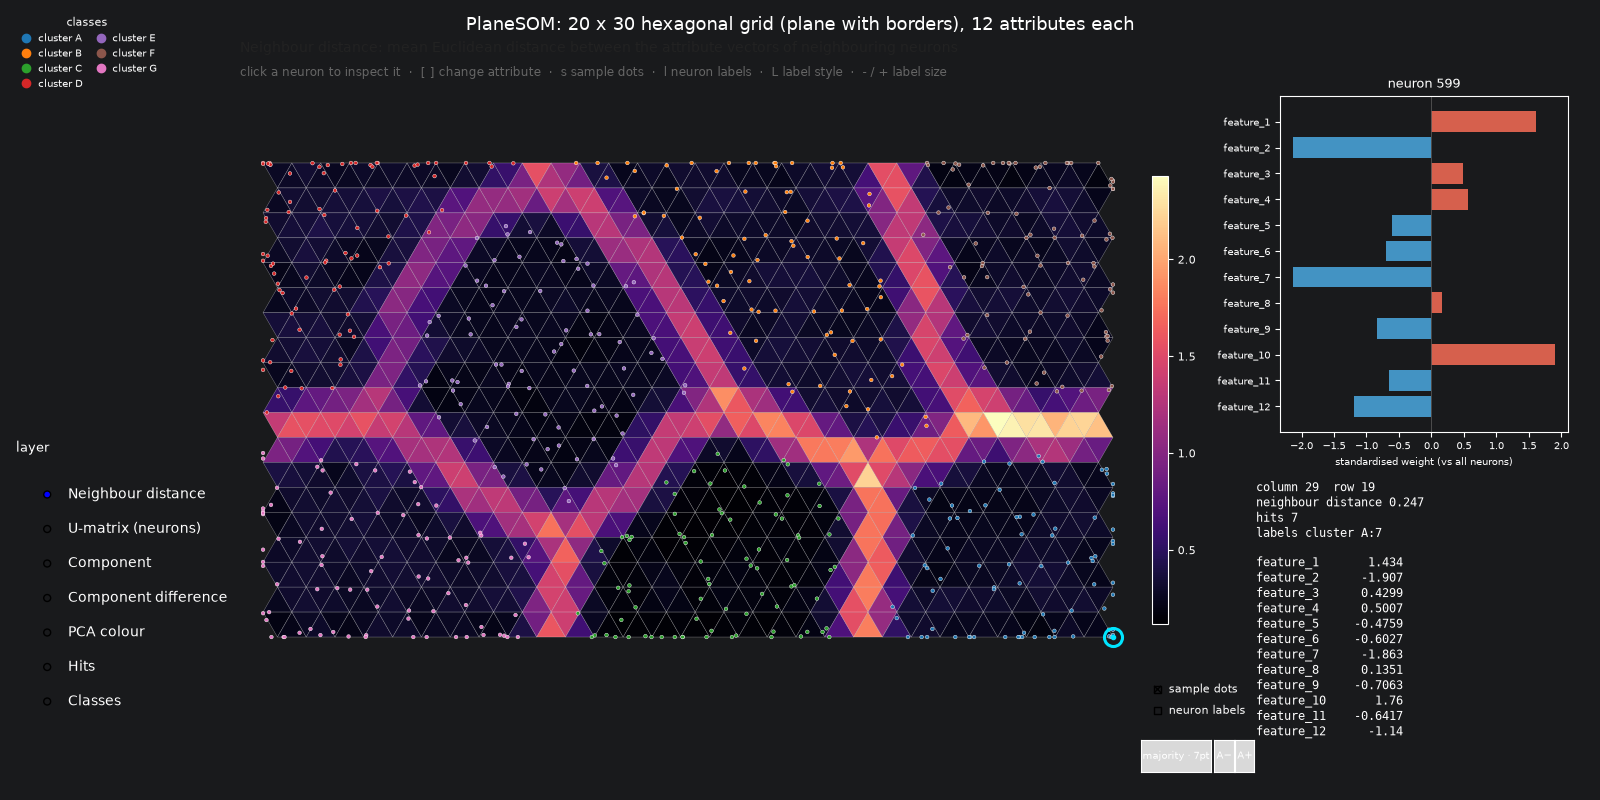

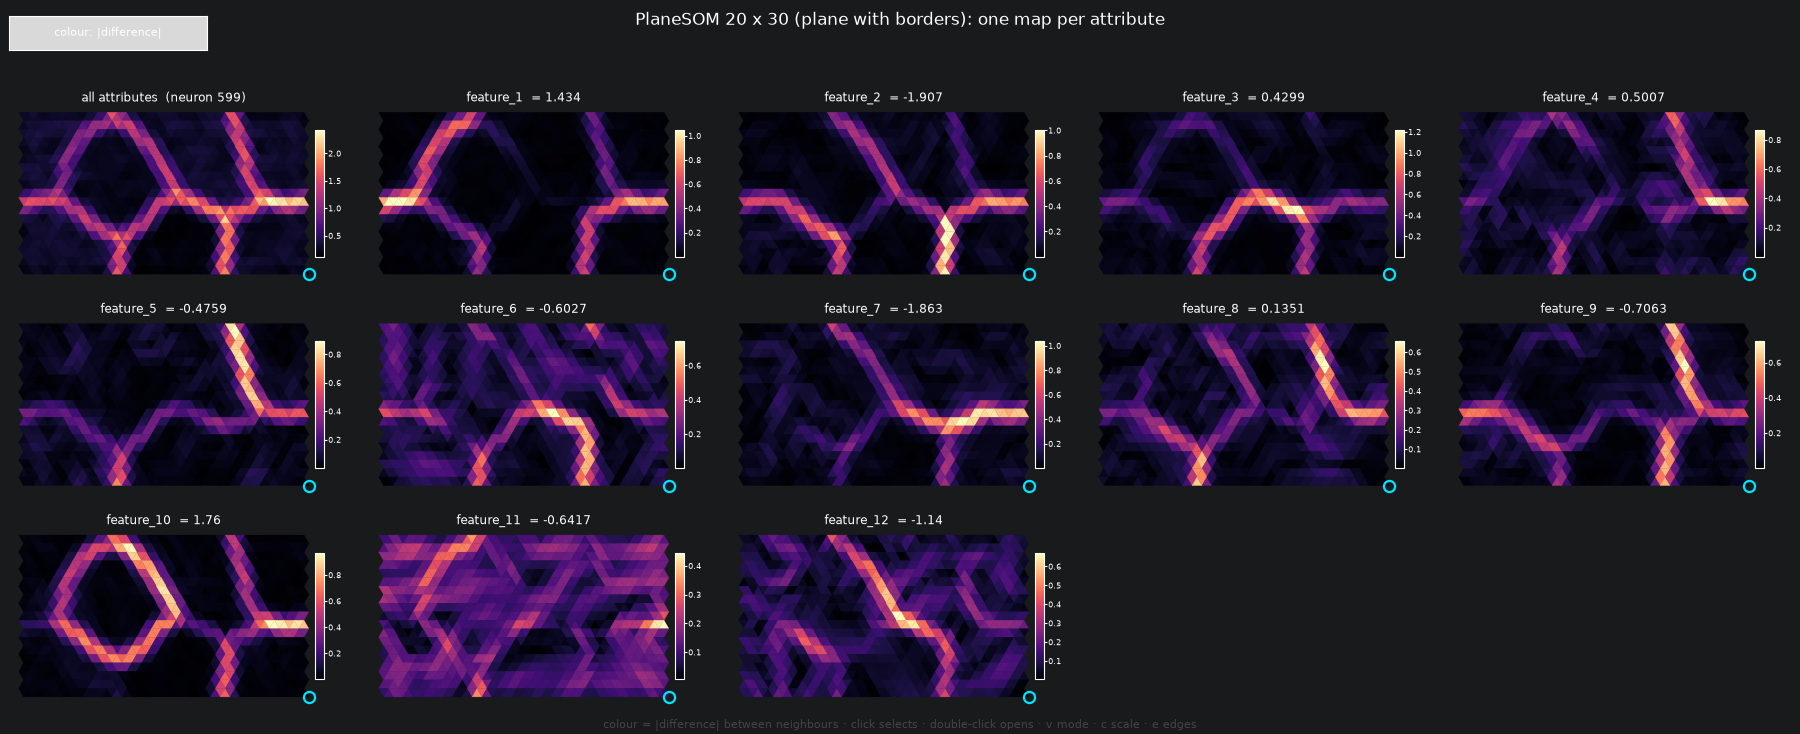

In [7]:
views = explore(som, x, labels, names, select=busiest, show=False)

### Controls

Pick a layer (and, for the *Component* layers, an attribute), select a neuron, or turn on the neuron labels.
The matrix view follows the selection.

In [8]:
nb_setup.controls(views.map, views.matrix)

Output()

### Try it: train your own

Choose the data and the shape of the map, then press **Run Interact**. A torus has no borders, so clusters are
never squeezed against an edge.

In [9]:
@widgets.interact_manual(data=widgets.Dropdown(options=[*datasets.samples(), 'colours'], value='wine'),
                         lattice=widgets.ToggleButtons(options=['hexagonal', 'rectilinear']),
                         topology=widgets.ToggleButtons(options=['plane', 'torus']),
                         rows=widgets.IntSlider(value=16, min=4, max=40),
                         cols=widgets.IntSlider(value=24, min=4, max=60),
                         epochs=widgets.IntSlider(value=30, min=1, max=100))
def train_plane(data, lattice, topology, rows, cols, epochs):
    x, labels, names = datasets.load(data)
    if data != 'colours':
        x = datasets.standardise(x)
    som = PlaneSOM(rows, cols, lattice=Lattice.Hexagonal if lattice == 'hexagonal' else Lattice.Rectilinear,
                   topology=Topology.Donut if topology == 'torus' else Topology.Plane, seed=0)
    som.initialise(InitializationType.Linear, x)
    som.train(x, epochs=epochs)
    print(f'{som}: QE {som.quantisation_error(x):.3f}, TE {som.topographic_error(x):.3f}')
    with nb_setup.building():
        views = explore(som, x, labels, names, select=int(np.argmax(som.hits(x))), show=False)
    nb_setup.show(views.map)
    nb_setup.controls(views.map, views.matrix)

interactive(children=(Dropdown(description='data', index=4, options=('animals', 'clusters', 'iris', 'penguins'…